In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

  Activating project at `~/DART`


In [2]:
Pkg.instantiate()

┌ Warning: Circular dependency detected. Precompilation will be skipped for:
│   OrdinaryDiffEqExplicitRK [9286f039-9fbf-40e8-bf65-aa933bdc4db0]
│   NonlinearSolveBaseBandedMatricesExt [f3d6eb4f-59b9-5696-a638-eddf66c7554e]
│   NonlinearSolveFirstOrder [5959db7a-ea39-4486-b5fe-2dd0bf03d60d]
│   Catalyst [479239e8-5488-4da2-87a7-35f2df7eef83]
│   NonlinearSolveBaseSparseMatrixColoringsExt [e3ecd195-ca82-5397-9546-f380c1e34951]
│   LinearSolveKernelAbstractionsExt [385e4588-a1a0-5c1d-98fa-d45bf6f8ecf9]
│   SparseConnectivityTracerNaNMathExt [1196811c-ab8c-56f5-92ba-b57bfe034832]
│   PreallocationTools [d236fae5-4411-538c-8e31-a6e3d9e00b46]
│   SparseDiffToolsZygoteExt [8fc09678-be9c-5e02-9277-3b8563c9ff11]
│   OrdinaryDiffEqCore [bbf590c4-e513-4bbe-9b18-05decba2e5d8]
│   ChainRules [082447d4-558c-5d27-93f4-14fc19e9eca2]
│   SpecialFunctionsExt [1285c0f1-ff9f-5867-b66e-0f359bcf09ba]
│   SciMLOperatorsStaticArraysCoreExt [a2df0a61-553a-563b-aed7-0ce21874eb58]
│   DiffEqBaseChainRulesCoreEx

In [3]:
using PyPlot, JLD2, DataFrames, CSV, Statistics

In [5]:
using Printf, MAT

#### Fig 4A

In [6]:
data_dir = "../synthetic_data";

In [9]:
function compute_acc(level::String, traces, cv::Int;
                     ntraces::Int = 300,
                     boot::Int = 1)

    biaccs  = Float64[]
    dlaccs  = Float64[]
    cpaccs  = Float64[]
    hmmaccs = Float64[]

    @load joinpath(data_dir, "real_cv$(cv)_data_res", "ngen_dl$(level)_compare_seed_1.jld2") rn_met_dl
    @load joinpath(data_dir, "bI_compare_cv$(cv)", "gen$(level)_hmm_cv$(cv).jld2") rn_binar_filter rn_met_binar error_ids

    base_bi = joinpath(data_dir, "bI_compare_cv$(cv)", "bI$(level)_acc$(cv)")
    cp_dir  = joinpath(data_dir, "cp_gen$(level)_cv$(cv)")

    # helper: pick short_cv first; otherwise long_cv; return nothing if missing
    function find_bi_csv(g::Int)
        p1 = joinpath(base_bi, "short_cv", "gene_$(g)_SINGLE_CELL_POSTERIOR.csv")
        isfile(p1) && return p1
        p2 = joinpath(base_bi, "long_cv",  "gene_$(g)_SINGLE_CELL_POSTERIOR.csv")
        isfile(p2) && return p2
        return nothing
    end

    for g in 1:20
        # ---------- Key change (写法A): require cp file ----------
        mat_fn = joinpath(cp_dir, @sprintf("viterbi_all_bin%d_boot%02d.mat", g, boot))
        isfile(mat_fn) || continue

        gene_traces = traces[g].trace
        idx         = traces[g].idx

        # ---------- burstInfer (bI) ----------
        csv_path = find_bi_csv(g)
        csv_path === nothing && continue

        bi_df = CSV.read(csv_path, DataFrame)
        n = min(ntraces, size(bi_df, 1), length(gene_traces))
        bi_acc = mean(mean(collect(bi_df[j, :]) .== gene_traces[j]) for j in 1:n)
        push!(biaccs, bi_acc)

        # ---------- DART ----------
        push!(dlaccs, rn_met_dl[idx].acc)

        # ---------- cpHMM ----------
        cp = matread(mat_fn)
        zv = cp["viterbi_all"]["z_viterbi"]

        ncp = min(ntraces, length(zv), length(gene_traces))
        cp_acc = mean(mean(Float64.(vec(zv[j]) .- 1) .== gene_traces[j]) for j in 1:ncp)
        push!(cpaccs, cp_acc)
    end

    # ---------- HMM (from rn_binar_filter) ----------
    append!(hmmaccs, (x.acc for x in rn_binar_filter))

    return dlaccs, biaccs, cpaccs, hmmaccs
end;

function load_accs(cv::Int)
    @load joinpath(data_dir,"bI_compare_cv$(cv)/genb_traces.jld2") genb_traces
    @load joinpath(data_dir,"bI_compare_cv$(cv)/gennb1_traces.jld2") gennb1_traces
    @load joinpath(data_dir,"bI_compare_cv$(cv)/gennb0_traces.jld2") gennb0_traces
    #@load "synthetic_compare_acc$(cv)/gennb1_traces.jld2" gennb1_traces

    res_b   = mean.(compute_acc("b", genb_traces, cv))
    res_nb1 = mean.(compute_acc("nb1", gennb1_traces, cv))
    res_nb0 = mean.(compute_acc("nb0", gennb0_traces, cv))

    values_dl  = [res_b[1], res_nb1[1], res_nb0[1]]
    values_bi  = [res_b[2], res_nb1[2], res_nb0[2]]
    values_cp = [res_b[3], res_nb1[3], res_nb0[3]]
    values_hmm = [res_b[4], res_nb1[4], res_nb0[4]]
    

    return values_dl, values_bi, values_cp, values_hmm
end;

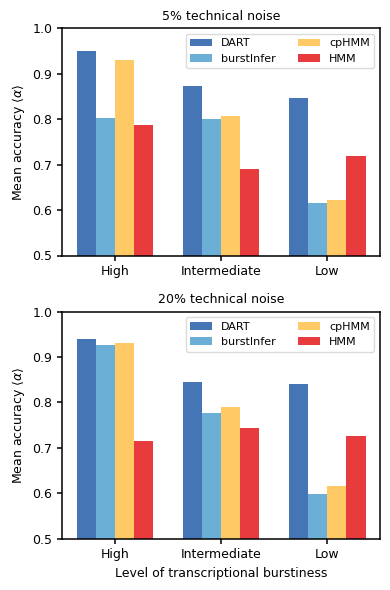

In [10]:
labels = ["High", "Intermediate", "Low"]
x = 1:length(labels)

width = 0.18
fs = 9

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(4, 6), sharey=true)

cvs    = [0, 2]
titles = ["5% technical noise", "20% technical noise"]

# 4 bars: centers at -1.5, -0.5, +0.5, +1.5 (times width)
offsets = (-1.5, -0.5, 0.5, 1.5) .* width

for (i, (cv, ax)) in enumerate(zip(cvs, (ax0, ax1)))
    values_dl, values_bi, values_cp, values_hmm = load_accs(cv)

    ax.bar(x .+ offsets[1], values_dl,  width, label="DART",       color="#4575b4")
    ax.bar(x .+ offsets[2], values_bi,  width, label="burstInfer", color="#6baed6")
    ax.bar(x .+ offsets[3], values_cp,  width, label="cpHMM",      color="#ffc966")
    ax.bar(x .+ offsets[4], values_hmm, width, label="HMM",        color="#e73b3d")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(titles[i], fontsize=fs)
    ax.legend(fontsize=8, frameon=true, ncol=2, facecolor="white", edgecolor="lightgrey")
    ax.set_ylabel(L"Mean accuracy $\langle \alpha \rangle$", fontsize=fs)

    wd = 1.1
    ax.tick_params(axis="both", labelsize=9, width=wd)
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end
end

ax1.set_xlabel("Level of transcriptional burstiness", fontsize=fs)
plt.tight_layout()
#fig.savefig("figs/DL_noise_compare_short.pdf", bbox_inches="tight");

#### 4B

In [21]:
data_dir = "synthetic_data";

cp_load = matread("../synthetic_data/example_traces/viterbi_all_bin1_boot01.mat")
cp_res = cp_load["viterbi_all"]["z_viterbi"];

@load "../synthetic_data/example_traces/dl_eg_traces.jld2" dl_eg_traces

@load "../synthetic_data/example_traces/gennb0_trace.jld2" gennb0_trace;

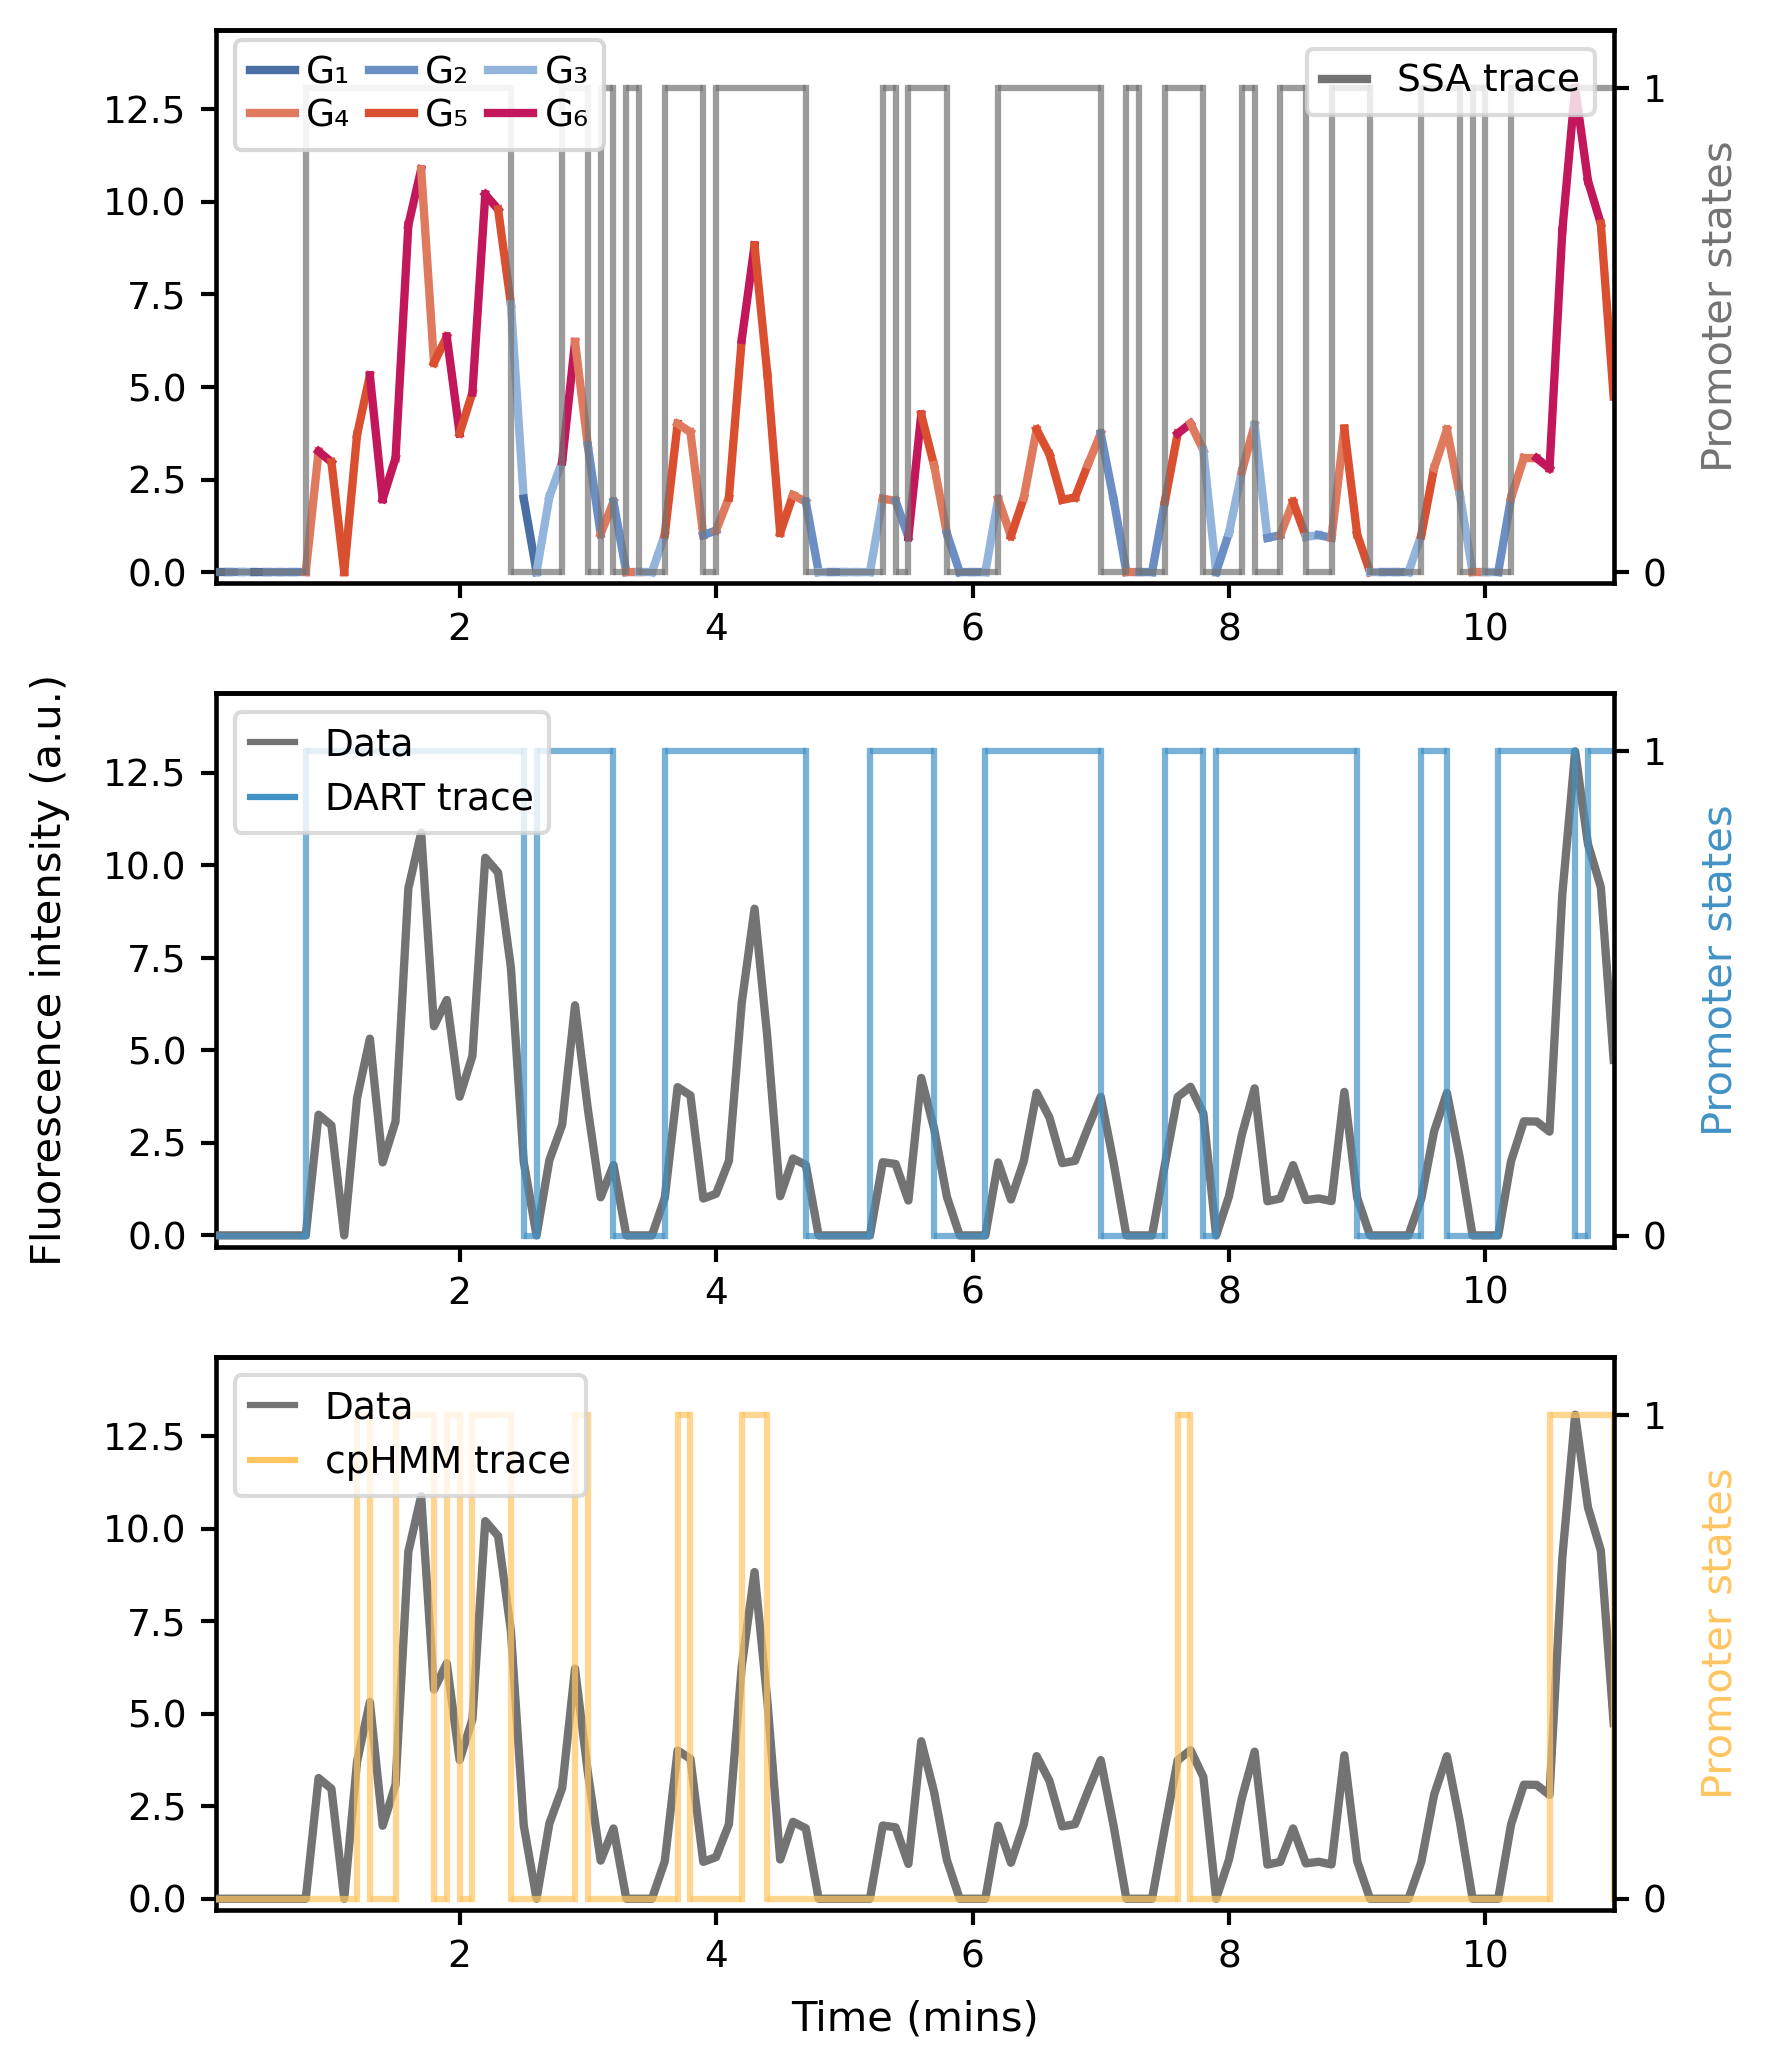

In [24]:
fig, axes = subplots(3, 1, figsize=(6, 7), dpi=300)
fs = 10
wd = 1.1
binary_color = "#737373"

trace_id = 1
cell_id = 41
t_int = 1:110
x = 0.1 .* (1:length(t_int))
signal = gennb0_trace[trace_id].nsyn[cell_id][t_int]
sig_max = maximum(signal) * 1.12
offset1 = 0.3
offset2 = 1.1 * offset1 / sig_max

states = gennb0_trace[trace_id].trace[cell_id][t_int]
promoter_traces = [
    Float64.(states .> 2),
    dl_eg_traces[291*(cell_id-1)+1 : 291*cell_id][t_int],
    (cp_res[cell_id] .- 1)[t_int]
]
labels = ["SSA trace", "DART trace", "cpHMM trace"]
colors_bin = [binary_color, "#4292c6", "#ffc560"]

state_colors = ["#4A6FA5", "#6B8EC4", "#93B5DC", "#E07A5F", "#D94F30", "#C2185B"]
state_labels = ["G₁", "G₂", "G₃", "G₄", "G₅", "G₆"]
n = length(x)

for i in 1:3
    ax1 = axes[i]

    # Left axis: colored signal for row 1, grey for rows 2–3
    if i == 1
        for j in 1:(n-1)
            s = Int(states[j]) + 1
            ax1.plot([x[j], x[j+1]], [signal[j], signal[j+1]];
                     color=state_colors[s], linewidth=2.0, zorder=3)
        end
    else
        ax1.plot(x, signal; color="#737373", lw=2.0, zorder=3)
    end

    ax1.set_ylim(-offset1, sig_max)
    ax1.set_xlim(x[1], x[end])

    # Right axis: binary trace
    ax2 = ax1.twinx()
    bt = promoter_traces[i]
    for j in 1:(n-1)
        ax2.plot([x[j], x[j+1]], [bt[j], bt[j]];
                 color=colors_bin[i], linewidth=1.5, solid_capstyle="butt",
                 alpha=0.7, zorder=1)
        if bt[j+1] != bt[j]
            ax2.plot([x[j+1], x[j+1]], [bt[j], bt[j+1]];
                     color=colors_bin[i], linewidth=1.5, alpha=0.7, zorder=1)
        end
    end
    ax2.set_ylim(-offset2, 1.12)
    ax2.set_yticks([0, 1])
    ax2.set_ylabel("Promoter states", fontsize=fs, labelpad=8, color =colors_bin[i])

    # Spines
    for ax in (ax1, ax2)
        ax.spines["top"].set_visible(true)
        ax.spines["top"].set_linewidth(wd)
    end
    ax1.spines["left"].set_linewidth(wd)
    ax1.spines["bottom"].set_linewidth(wd)
    ax1.spines["right"].set_visible(false)
    ax2.spines["right"].set_linewidth(wd)
    ax2.spines["left"].set_visible(false)
    ax2.spines["bottom"].set_visible(false)

    ax1.tick_params(; axis="both", labelsize=9, width=1.0)
    ax2.tick_params(; axis="both", labelsize=9, width=1.0)

    if i == 2
        ax1.set_ylabel("Fluorescence intensity (a.u.)", fontsize=fs, labelpad=8)
    end
    if i == 3
        ax1.set_xlabel("Time (mins)", fontsize=fs, labelpad=6)
    end

    # Legend
    if i == 1
        # Legend 1: G1–G6
        row_order = [1, 4, 2, 5, 3, 6]
        sh = [plt.Line2D([0], [0]; color=state_colors[k], lw=2.0) for k in row_order]
        sl = [state_labels[k] for k in row_order]
        leg1 = ax2.legend(sh, sl;
            loc="lower left", bbox_to_anchor=(0.0, 0.75), fontsize=9,
            frameon=true, framealpha=0.9, edgecolor="lightgrey", facecolor="white",
            handlelength=1.2, ncol=3, columnspacing=0.5, labelspacing=0.2, handletextpad=0.3)
        leg1.set_zorder(999)
        ax2.add_artist(leg1)  # keep leg1 when adding leg2

        # Legend 2: SSA trace
        h_ssa = plt.Line2D([0], [0]; color=binary_color, lw=2.0)
        leg2 = ax2.legend([h_ssa], ["SSA trace"];
            loc="upper right", fontsize=9, frameon=true,
            facecolor="white", edgecolor="lightgrey", handlelength=1.2)
        leg2.set_zorder(999)
    else
        h_sig = plt.Line2D([0], [0]; color="#737373", lw=1.5)
        h_bin = plt.Line2D([0], [0]; color=colors_bin[i], lw=1.5)
        leg = ax2.legend([h_sig, h_bin], ["Data", labels[i]];
            loc="upper left", fontsize=9, frameon=true,
            facecolor="white", edgecolor="lightgrey", handlelength=1.2)
        leg.set_zorder(999)
    end
end

tight_layout()
#savefig("Figures/figs/DL_compare_eg.pdf", bbox_inches="tight")